# Trabajo Práctico - Aprendizaje Automático

Integrantes del grupo 'Pablo Brusco Galactico':
- Tomas Mele
- Mario Livia Auqui
- Ignacio Lucas Rodriguez
- Mauricio Enrich
- Facundo Sanchez

## SetUp




In [492]:
import math

from six import StringIO 
from IPython.display import Image, display
import pydotplus

import numpy as np
import pandas as pd
import pingouin as pg
from scipy.stats import shapiro

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.model_selection import (cross_validate, StratifiedKFold, ParameterGrid, RandomizedSearchCV)

from sklearn.calibration import CalibratedClassifierCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (accuracy_score, average_precision_score, precision_recall_curve, recall_score, roc_auc_score, roc_curve, auc, precision_score, f1_score)

In [493]:
# Seteamos la semilla para que los resultados sean reproducibles
SEED = 2026
np.random.seed(SEED)

# Definimos el K-Fold estratificado para usar en la validación cruzada de los modelos
stratifiedKFold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

### Definición de Funciones

In [494]:
df_completo = pd.read_csv('data.csv')

In [495]:
from dataclasses import dataclass

@dataclass
class InformeCompleto:
    informe: pd.DataFrame
    y_global_true: pd.DataFrame
    y_global_proba: pd.DataFrame
    y_global_pred: pd.DataFrame

## Ejercicio 1

### Ejercico 1.1 
Vamos a mantener proporciones de las clases en los conjuntos de Desarrollo y Control.

In [496]:
# Función para separar el dataset en train y test, manteniendo la proporción de clases
# p = proporción de datos para control
def train_test_split(df, p=0.2):
    # Separo las filas por clase
    filas_y1 = df[df['target'] == 1] #las filas con y = 1
    filas_y0 = df[df['target'] == 0] # con y = 0
    
    prop_buen_pronostico = filas_y1.shape[0]/df.shape[0]
    print("Proporción de clase positiva: ", prop_buen_pronostico) # La proporción de los datos dados es del 0.282

    cant_buen_pronostico = int(df.shape[0] * p *    prop_buen_pronostico)
    cant_mal_pronostico = int(df.shape[0] * p * (1-prop_buen_pronostico))

    test = pd.DataFrame(columns=filas_y1.columns).astype(filas_y1.dtypes) #hago db con las columnas
    test = pd.concat([test, filas_y1.sample(n=cant_buen_pronostico, random_state=SEED)], ignore_index=False) #sampleo 
    test = pd.concat([test, filas_y0.sample(n=cant_mal_pronostico, random_state=SEED)], ignore_index=False)

    train = df.drop(test.index, axis=0)

    return train.drop(columns=['target']), train['target'], test.drop(columns=['target']), test['target']

In [497]:
# Definimos el dataset que usaremos para desarrollar el modelo y el dataset de control que usaremos para evaluar el modelo.
X_train, y_train, X_control, y_control = train_test_split(df_completo)

df_control = pd.concat([X_control, y_control], axis=1)
df = pd.concat([X_train, y_train], axis=1)

Proporción de clase positiva:  0.282


## Ejercicio 2

In [498]:
# Función para entrenar un árbol de decisión con una semilla fija
def train_tree(X_tr: np.ndarray, y_tr: np.ndarray, tree_params={}) -> DecisionTreeClassifier:
    arbol = DecisionTreeClassifier(**tree_params, random_state=SEED)
    arbol.fit(X_tr, y_tr)

    return arbol

### Ejercicio 2.1

In [499]:
X_train, y_train, X_test, y_test = train_test_split(df)

tree_1 = train_tree(X_train, y_train, tree_params={'max_depth': 3})

print("Score sobre el dataset de entrenamiento: ", tree_1.score(X_train, y_train))
print("Score sobre el dataset de prueba: ", tree_1.score(X_test, y_test))


Proporción de clase positiva:  0.2817955112219451
Score sobre el dataset de entrenamiento:  0.8478260869565217
Score sobre el dataset de prueba:  0.6455696202531646


### Ejercicio 2.2

In [500]:
def stratifiedKFoldCV(algoritmo, X_train, y_train, cv, umbral=0.5):

    resultados_folds = []
    
    y_global_true = np.empty(len(y_train))
    y_global_pred = np.empty(len(y_train))
    y_global_proba = np.empty(len(y_train))

    for fold_idx, (train_index, val_index) in enumerate(cv.split(X_train, y_train)):

        kf_X_train, kf_X_test = X_train.iloc[train_index], X_train.iloc[val_index]
        kf_y_train, kf_y_test = y_train.iloc[train_index], y_train.iloc[val_index]

        algoritmo.fit(kf_X_train, kf_y_train)

        y_pred_proba_train = algoritmo.predict_proba(kf_X_train)[:, 1]
        y_pred_proba_test = algoritmo.predict_proba(kf_X_test)[:, 1]

        y_pred_train = (y_pred_proba_train >= umbral).astype(int)
        y_pred_test = (y_pred_proba_test >= umbral).astype(int)

        y_global_true[val_index] = kf_y_test
        y_global_proba[val_index] = y_pred_proba_test
        y_global_pred[val_index] = y_pred_test

        acc_por_clase = recall_score(y_true=kf_y_test, y_pred=y_pred_test, average=None)
        precision_por_clase = precision_score(kf_y_test, y_pred_test, average=None, zero_division=0)

        resultados_folds.append({
            'Permutación': str(fold_idx + 1),
            'Accuracy (train)': accuracy_score(kf_y_train, y_pred_train),
            'Accuracy (val.)': accuracy_score(kf_y_test, y_pred_test),
            'AUC-PRC (train)': average_precision_score(kf_y_train, y_pred_proba_train),
            'AUC-PRC (val.)': average_precision_score(kf_y_test, y_pred_proba_test),
            'AUC-ROC (train)': roc_auc_score(kf_y_train, y_pred_proba_train),
            'AUC-ROC (val.)': roc_auc_score(kf_y_test, y_pred_proba_test),
            'Precision Mayoritaria': precision_por_clase[0],
            'Precision Minoritaria': precision_por_clase[1],
            'F1 (val.)': f1_score(kf_y_test, y_pred_test, zero_division=0),
            'Acc Mayoritaria': acc_por_clase[0],
            'Acc Minoritaria': acc_por_clase[1]
        })

    df_tabla = pd.DataFrame(resultados_folds)

    promedios = df_tabla.drop(columns=['Permutación']).mean()
    df_tabla.loc[len(df_tabla)] = ['Promedios'] + list(promedios)

    global_acc_por_clase = recall_score(y_true=y_global_true, y_pred=y_global_pred, average=None)
    global_precision_por_clase = precision_score(y_true=y_global_true, y_pred=y_global_pred, average=None, zero_division=0)
    
    df_tabla.loc[len(df_tabla)] = [
        'Global',
        '(NO)',
        accuracy_score(y_global_true, y_global_pred),
        '(NO)',
        average_precision_score(y_global_true, y_global_proba),
        '(NO)',
        roc_auc_score(y_global_true, y_global_proba),
        global_precision_por_clase[0],
        global_precision_por_clase[1],
        f1_score(y_global_true, y_global_pred, zero_division=0),
        global_acc_por_clase[0],
        global_acc_por_clase[1]
    ]

    resultado = InformeCompleto(
        informe=df_tabla,
        y_global_true=y_global_true,
        y_global_proba=y_global_proba,
        y_global_pred=y_global_pred,        
    )
    
    return resultado

In [501]:
tree_3 = DecisionTreeClassifier(max_depth=3, random_state=SEED)
X_train, y_train = df.drop(columns=['target']), df['target']

resultado_tree_1 = stratifiedKFoldCV(tree_3, X_train, y_train, stratifiedKFold)

resultado_tree_1.informe

,Permutación,Accuracy (train),Accuracy (val.),AUC-PRC (train),AUC-PRC (val.),AUC-ROC (train),AUC-ROC (val.),Precision Mayoritaria,Precision Minoritaria,F1 (val.),Acc Mayoritaria,Acc Minoritaria
0,1,0.825,0.728395,0.688876,0.457783,0.843647,0.720765,0.800000,0.523810,0.500000,0.827586,0.478261
1,2,0.841121,0.612500,0.692027,0.353266,0.864142,0.618730,0.800000,0.371429,0.456140,0.620690,0.590909
2,3,0.813084,0.687500,0.658068,0.420417,0.846417,0.737069,0.732394,0.333333,0.193548,0.896552,0.136364
3,4,0.82866,0.650000,0.70596,0.412458,0.870659,0.670862,0.716418,0.307692,0.222222,0.842105,0.173913
4,5,0.831776,0.612500,0.682425,0.372447,0.849254,0.673150,0.732143,0.333333,0.340426,0.719298,0.347826
5,Promedios,0.827928,0.658179,0.685471,0.403274,0.854824,0.684115,0.756191,0.373919,0.342467,0.781246,0.345455
6,Global,(NO),0.658354,(NO),0.394941,(NO),0.682922,0.752508,0.382353,0.362791,0.781250,0.345133


### Ejercicio 2.3

In [502]:
def grid_search_tree(X_train, y_train, param_grid={'max_depth': [3,5,None], 'criterion': ['gini', 'entropy']}, metric='accuracy'):
    grid = ParameterGrid(param_grid)
    res = []
    
    for params in grid:
        current_tree = DecisionTreeClassifier(**params, random_state=SEED)
        
        cv_results = cross_validate(
            current_tree, 
            X_train, 
            y_train, 
            cv=stratifiedKFold, 
            scoring=metric, 
            return_train_score=True 
        )
        
        fila = {}
        for param_name, param_value in params.items():
            if param_name == 'max_depth' and param_value is None:
                fila[param_name] = 'Infinito'
            else:
                fila[param_name] = param_value
                
        fila[f'{metric} (training)'] = cv_results['train_score'].mean()
        fila[f'{metric} (validación)'] = cv_results['test_score'].mean()
        
        res.append(fila)

    return pd.DataFrame(res)

In [503]:
X_train, y_train = df.drop(columns=['target']), df['target']
res_grid_search_tree = grid_search_tree(X_train, y_train)

In [504]:
res_grid_search_tree

,criterion,max_depth,accuracy (training),accuracy (validación)
0,gini,3,0.827928,0.658179
1,gini,5,0.933289,0.683179
2,gini,Infinito,1.000000,0.685710
3,entropy,3,0.803621,0.678241
4,entropy,5,0.885923,0.655741
5,entropy,Infinito,1.000000,0.658148


## Ejercicio 3

In [505]:
# Función para generar una tabla de resultados a partir de un objeto RandomizedSearchCV entrenado
def generar_tabla_resultados(busqueda_entrenada):
    df_resultados = pd.DataFrame(busqueda_entrenada.cv_results_)
    
    columnas_params = [col for col in df_resultados.columns if col.startswith('param_')]
    columnas_metricas = [
        'rank_test_score',
        'mean_test_score',
        'std_test_score'
    ]

    columnas_totales = columnas_metricas + columnas_params
    tabla_limpia = df_resultados[columnas_totales].sort_values(by='rank_test_score')
    
    mapeo_nombres = {col: col.replace('param_', '') for col in columnas_params}
    tabla_limpia = tabla_limpia.rename(columns=mapeo_nombres)

    return tabla_limpia

# Mean aca es AUCROC


# Punto ideal: (FPR=0, TPR=1)
def umbral_optimo_distancia_01(modelo):
    X_train, y_train = df.drop(columns=['target']), df['target']

    # Como el randomizado está fijo, y_global_proba siempre va a ser el mismo para un mismo modelo, mismos datos y mismo cv
    res = stratifiedKFoldCV(modelo, X_train, y_train, stratifiedKFold)
    y_global_true = res.y_global_true
    y_global_proba = res.y_global_proba

    fpr, tpr, thresholds_roc = roc_curve(y_global_true, y_global_proba)
    distancias = np.sqrt(fpr**2 + (1 - tpr)**2)
    idx_mejor = np.argmin(distancias)
    mejor_umbral_dist = thresholds_roc[idx_mejor]

    return mejor_umbral_dist

### Ejercicio 3.1

#### Árboles de Decisión

In [506]:
X_train, y_train = df.drop(columns=['target']), df['target']

random_search_tree = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=SEED),
    param_distributions={
        'max_depth': [3, 4, 5, 6, 7, None],
        'criterion': ['gini', 'entropy'],
        'max_features' : [None, 'sqrt', 'log2'],
        'min_samples_split' : [15, 20, 25, 30, 35, 40],
    }, # restringe el espacio de búsqueda a estos valores
    n_iter=50, # combinaciones aleatorias a probar
    scoring='roc_auc', # métrica a optimizar
    cv=stratifiedKFold,
    random_state=SEED,
    return_train_score=True,
    n_jobs=-1 # esto permite usar todos los cores de CPU
)

random_search_tree.fit(X_train, y_train)

generar_tabla_resultados(random_search_tree).head(5)

,rank_test_score,mean_test_score,std_test_score,min_samples_split,max_features,max_depth,criterion
34,1,0.689762,0.039909,15,None,4,gini
29,2,0.677776,0.027625,25,None,6,gini
37,3,0.676666,0.031379,35,None,7,gini
5,4,0.670628,0.057329,40,None,3,gini
10,5,0.659342,0.060670,20,None,5,gini


In [507]:
# Buscamos el umbral optimo
umbral_optimo_tree = umbral_optimo_distancia_01(random_search_tree.best_estimator_)

print("Umbral óptimo para el modelo Decision Tree: ", umbral_optimo_tree)

Umbral óptimo para el modelo Decision Tree:  0.1791044776119403


In [508]:
# Resultados del modelo Decision Tree con su mejor combinación de hiperparámetros más otras métricas de evaluación
resultado_tree = stratifiedKFoldCV(random_search_tree.best_estimator_, X_train, y_train, stratifiedKFold)

resultado_tree.informe

,Permutación,Accuracy (train),Accuracy (val.),AUC-PRC (train),AUC-PRC (val.),AUC-ROC (train),AUC-ROC (val.),Precision Mayoritaria,Precision Minoritaria,F1 (val.),Acc Mayoritaria,Acc Minoritaria
0,1,0.8625,0.740741,0.801101,0.481555,0.910242,0.736882,0.803279,0.550000,0.511628,0.844828,0.478261
1,2,0.88162,0.687500,0.82023,0.414409,0.91001,0.670455,0.811321,0.444444,0.489796,0.741379,0.545455
2,3,0.862928,0.700000,0.778087,0.408338,0.912279,0.724922,0.783333,0.450000,0.428571,0.810345,0.409091
3,4,0.859813,0.625000,0.797928,0.348223,0.90938,0.625477,0.764706,0.379310,0.423077,0.684211,0.478261
4,5,0.897196,0.650000,0.84287,0.383492,0.913829,0.691076,0.737705,0.368421,0.333333,0.789474,0.304348
5,Promedios,0.872812,0.680648,0.808043,0.407203,0.911148,0.689762,0.780069,0.438435,0.437281,0.774047,0.443083
6,Global,(NO),0.680798,(NO),0.400002,(NO),0.691464,0.779720,0.434783,0.438596,0.774306,0.442478


In [509]:
# Resultados del modelo Decision Tree con su mejor combinación de hiperparámetros más otras métricas de evaluación
resultado_tree = stratifiedKFoldCV(random_search_tree.best_estimator_, X_train, y_train, stratifiedKFold, umbral=umbral_optimo_tree)

resultado_tree.informe

,Permutación,Accuracy (train),Accuracy (val.),AUC-PRC (train),AUC-PRC (val.),AUC-ROC (train),AUC-ROC (val.),Precision Mayoritaria,Precision Minoritaria,F1 (val.),Acc Mayoritaria,Acc Minoritaria
0,1,0.83125,0.703704,0.801101,0.481555,0.910242,0.736882,0.869565,0.485714,0.586207,0.689655,0.739130
1,2,0.872274,0.650000,0.82023,0.414409,0.91001,0.670455,0.857143,0.421053,0.533333,0.620690,0.727273
2,3,0.766355,0.662500,0.778087,0.408338,0.912279,0.724922,0.860465,0.432432,0.542373,0.637931,0.727273
3,4,0.859813,0.625000,0.797928,0.348223,0.90938,0.625477,0.764706,0.379310,0.423077,0.684211,0.478261
4,5,0.735202,0.662500,0.84287,0.383492,0.913829,0.691076,0.826087,0.441176,0.526316,0.666667,0.652174
5,Promedios,0.812979,0.660741,0.808043,0.407203,0.911148,0.689762,0.835593,0.431937,0.522261,0.659831,0.664822
6,Global,(NO),0.660848,(NO),0.400002,(NO),0.691464,0.833333,0.433526,0.524476,0.659722,0.663717


#### KNN

In [510]:
X_train, y_train = df.drop(columns=['target']), df['target']

random_search_KNN = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions={
        'n_neighbors': range(1,20),
        'weights': ["uniform","distance"],
        'metric':["cityblock","cosine","euclidean"]
    }, 
    n_iter=30, 
    scoring='roc_auc',
    cv=stratifiedKFold,
    random_state=SEED,
    return_train_score=True,
    
)

random_search_KNN.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'metric': ['cityblock', 'cosine', ...], 'n_neighbors': range(1, 20), 'weights': ['uniform', 'distance']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",2026
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for 

In [511]:
generar_tabla_resultados(random_search_KNN).head(5)

,rank_test_score,mean_test_score,std_test_score,weights,n_neighbors,metric
10,1,0.852107,0.045036,distance,17,cosine
19,2,0.850399,0.051142,distance,19,cosine
12,3,0.847565,0.035866,distance,14,cosine
21,4,0.845835,0.039610,distance,11,cosine
27,5,0.844719,0.043188,uniform,18,cityblock


In [512]:
# Buscamos el umbral optimo
umbral_optimo_knn = umbral_optimo_distancia_01(random_search_KNN.best_estimator_)

print("Umbral óptimo para el modelo KNN: ", umbral_optimo_knn)

Umbral óptimo para el modelo KNN:  0.24730068416165038


In [513]:
# Resultados del modelo KNN con su mejor combinación de hiperparámetros más otras métricas de evaluación
resultado_knn = stratifiedKFoldCV(random_search_KNN.best_estimator_, X_train, y_train, stratifiedKFold)

resultado_knn.informe

,Permutación,Accuracy (train),Accuracy (val.),AUC-PRC (train),AUC-PRC (val.),AUC-ROC (train),AUC-ROC (val.),Precision Mayoritaria,Precision Minoritaria,F1 (val.),Acc Mayoritaria,Acc Minoritaria
0,1,1.0,0.753086,1.0,0.719046,1.0,0.875562,0.756757,0.714286,0.333333,0.965517,0.217391
1,2,1.0,0.825000,1.0,0.836137,1.0,0.921630,0.805556,1.000000,0.533333,1.000000,0.363636
2,3,1.0,0.775000,1.0,0.661723,1.0,0.812696,0.770270,0.833333,0.357143,0.982759,0.227273
3,4,1.0,0.737500,1.0,0.612980,1.0,0.795576,0.750000,0.625000,0.322581,0.947368,0.217391
4,5,1.0,0.787500,1.0,0.735661,1.0,0.855072,0.777778,0.875000,0.451613,0.982456,0.304348
5,Promedios,1.0,0.775617,1.0,0.713109,1.0,0.852107,0.772072,0.809524,0.399601,0.975620,0.266008
6,Global,(NO),0.775561,(NO),0.687866,(NO),0.850541,0.771978,0.810811,0.400000,0.975694,0.265487


In [514]:
# Resultados del modelo KNN con su mejor combinación de hiperparámetros más otras métricas de evaluación
resultado_knn = stratifiedKFoldCV(random_search_KNN.best_estimator_, X_train, y_train, stratifiedKFold, umbral=umbral_optimo_knn)

resultado_knn.informe

,Permutación,Accuracy (train),Accuracy (val.),AUC-PRC (train),AUC-PRC (val.),AUC-ROC (train),AUC-ROC (val.),Precision Mayoritaria,Precision Minoritaria,F1 (val.),Acc Mayoritaria,Acc Minoritaria
0,1,1.0,0.777778,1.0,0.719046,1.0,0.875562,0.916667,0.575758,0.678571,0.758621,0.826087
1,2,1.0,0.812500,1.0,0.836137,1.0,0.921630,0.938776,0.612903,0.716981,0.793103,0.863636
2,3,1.0,0.812500,1.0,0.661723,1.0,0.812696,0.905660,0.629630,0.693878,0.827586,0.772727
3,4,1.0,0.687500,1.0,0.612980,1.0,0.795576,0.900000,0.475000,0.603175,0.631579,0.826087
4,5,1.0,0.825000,1.0,0.735661,1.0,0.855072,0.905660,0.666667,0.720000,0.842105,0.782609
5,Promedios,1.0,0.783056,1.0,0.713109,1.0,0.852107,0.913353,0.591991,0.682521,0.770599,0.814229
6,Global,(NO),0.783042,(NO),0.687866,(NO),0.850541,0.913580,0.582278,0.678967,0.770833,0.814159


#### SVC

In [515]:
def mejor_SVC_dado_df(X_train, y_train):
    param_dist = [
        {
            'estimator__kernel': ['rbf'],
            'estimator__C': np.logspace(-3, 3, 7), 
            'estimator__gamma': list(np.logspace(-4, 1, 6)) + ['scale', 'auto'], 
        },
        {
            'estimator__kernel': ['poly'],
            'estimator__C': np.logspace(-3, 3, 7),
            'estimator__degree': [2, 3, 5],
            'estimator__coef0': [0.0, 0.1, 0.5],
        },
        {
            'estimator__kernel': ['linear'],
            'estimator__C': np.logspace(-3, 3, 7),
        },
    ]

    modelo_base = CalibratedClassifierCV(SVC(), ensemble=False)

    random_search_svc = RandomizedSearchCV(
        modelo_base,
        param_distributions=param_dist,
        n_iter=30,
        scoring='roc_auc',
        cv=stratifiedKFold,
        random_state=SEED,
        n_jobs=-1
    )
    
    random_search_svc.fit(X_train, y_train)
    return random_search_svc

In [516]:
X_train, y_train = df.drop(columns=['target']), df['target']

random_search_svc = mejor_SVC_dado_df(X_train, y_train)
random_search_svc.best_params_

{'estimator__kernel': 'rbf',
 'estimator__gamma': 'scale',
 'estimator__C': np.float64(100.0)}

In [517]:
generar_tabla_resultados(random_search_svc).head(5)

,rank_test_score,mean_test_score,std_test_score,estimator__kernel,estimator__degree,estimator__coef0,estimator__C,estimator__gamma
21,1,0.881452,0.058716,rbf,NaN,NaN,100.0,scale
28,2,0.867490,0.066420,poly,2.0,0.1,10.0,NaN
0,3,0.867359,0.066553,poly,2.0,0.1,1000.0,NaN
9,4,0.867036,0.054282,poly,3.0,0.5,1.0,NaN
19,5,0.862179,0.063622,poly,2.0,0.5,10.0,NaN


In [518]:
# Buscamos el umbral optimo
umbral_optimo_svc = umbral_optimo_distancia_01(random_search_svc.best_estimator_)   

print("Umbral óptimo para el modelo SVC: ", umbral_optimo_svc)

Umbral óptimo para el modelo SVC:  0.3031206741621296


In [519]:
# Resultados del modelo SVC con su mejor combinación de hiperparámetros más otras métricas de evaluación
resultado_svc = stratifiedKFoldCV(random_search_svc.best_estimator_, X_train, y_train, stratifiedKFold)

resultado_svc.informe

,Permutación,Accuracy (train),Accuracy (val.),AUC-PRC (train),AUC-PRC (val.),AUC-ROC (train),AUC-ROC (val.),Precision Mayoritaria,Precision Minoritaria,F1 (val.),Acc Mayoritaria,Acc Minoritaria
0,1,1.0,0.864198,1.0,0.825288,1.0,0.925787,0.873016,0.833333,0.731707,0.948276,0.652174
1,2,1.0,0.900000,1.0,0.918834,1.0,0.949843,0.890625,0.937500,0.789474,0.982759,0.681818
2,3,1.0,0.812500,1.0,0.696638,1.0,0.884796,0.852459,0.684211,0.634146,0.896552,0.590909
3,4,1.0,0.762500,1.0,0.631482,1.0,0.779558,0.806452,0.611111,0.536585,0.877193,0.478261
4,5,1.0,0.887500,1.0,0.835755,1.0,0.867277,0.900000,0.850000,0.790698,0.947368,0.739130
5,Promedios,1.0,0.845340,1.0,0.781600,1.0,0.881452,0.864510,0.783231,0.696522,0.930430,0.628458
6,Global,(NO),0.845387,(NO),0.743940,(NO),0.880470,0.864516,0.780220,0.696078,0.930556,0.628319


In [520]:
# Resultados del modelo SVC con su mejor combinación de hiperparámetros más otras métricas de evaluación
resultado_svc = stratifiedKFoldCV(random_search_svc.best_estimator_, X_train, y_train, stratifiedKFold, umbral=umbral_optimo_svc)

resultado_svc.informe

,Permutación,Accuracy (train),Accuracy (val.),AUC-PRC (train),AUC-PRC (val.),AUC-ROC (train),AUC-ROC (val.),Precision Mayoritaria,Precision Minoritaria,F1 (val.),Acc Mayoritaria,Acc Minoritaria
0,1,1.0,0.876543,1.0,0.825288,1.0,0.925787,0.944444,0.740741,0.800000,0.879310,0.869565
1,2,1.0,0.900000,1.0,0.918834,1.0,0.949843,0.962963,0.769231,0.833333,0.896552,0.909091
2,3,1.0,0.837500,1.0,0.696638,1.0,0.884796,0.941176,0.655172,0.745098,0.827586,0.863636
3,4,1.0,0.712500,1.0,0.631482,1.0,0.779558,0.840000,0.500000,0.566038,0.736842,0.652174
4,5,1.0,0.887500,1.0,0.835755,1.0,0.867277,0.913793,0.818182,0.800000,0.929825,0.782609
5,Promedios,1.0,0.842809,1.0,0.781600,1.0,0.881452,0.920475,0.696665,0.748894,0.854023,0.815415
6,Global,(NO),0.842893,(NO),0.743940,(NO),0.880470,0.921348,0.686567,0.744939,0.854167,0.814159


##### Hiperparámetros

### Ejercicio 3.2

#### LDA

In [521]:
X_train, y_train = df.drop(columns=['target']), df['target']
lda_model = LinearDiscriminantAnalysis()

# Buscamos el umbral optimo
umbral_optimo_lda = umbral_optimo_distancia_01(lda_model)

print("Umbral óptimo para el modelo LDA: ", umbral_optimo_lda)

Umbral óptimo para el modelo LDA:  0.025741498293617212


In [522]:
resultado_lda = stratifiedKFoldCV(lda_model, X_train, y_train, stratifiedKFold)

resultado_lda.informe

,Permutación,Accuracy (train),Accuracy (val.),AUC-PRC (train),AUC-PRC (val.),AUC-ROC (train),AUC-ROC (val.),Precision Mayoritaria,Precision Minoritaria,F1 (val.),Acc Mayoritaria,Acc Minoritaria
0,1,0.965625,0.629630,0.983121,0.338047,0.991353,0.565217,0.733333,0.333333,0.318182,0.758621,0.304348
1,2,0.975078,0.687500,0.991062,0.500857,0.99613,0.616771,0.800000,0.440000,0.468085,0.758621,0.500000
2,3,0.981308,0.575000,0.994273,0.302373,0.99785,0.545455,0.740000,0.300000,0.346154,0.637931,0.409091
3,4,0.956386,0.625000,0.975422,0.397509,0.990717,0.607933,0.754717,0.370370,0.400000,0.701754,0.434783
4,5,0.950156,0.750000,0.973055,0.642061,0.987975,0.797101,0.836364,0.560000,0.583333,0.807018,0.608696
5,Promedios,0.965711,0.653426,0.983387,0.436170,0.992805,0.626495,0.772883,0.400741,0.423151,0.732789,0.451383
6,Global,(NO),0.653367,(NO),0.394873,(NO),0.625737,0.772894,0.398438,0.423237,0.732639,0.451327


In [523]:
resultado_lda = stratifiedKFoldCV(lda_model, X_train, y_train, stratifiedKFold, umbral=umbral_optimo_lda)

resultado_lda.informe

,Permutación,Accuracy (train),Accuracy (val.),AUC-PRC (train),AUC-PRC (val.),AUC-ROC (train),AUC-ROC (val.),Precision Mayoritaria,Precision Minoritaria,F1 (val.),Acc Mayoritaria,Acc Minoritaria
0,1,0.825,0.592593,0.983121,0.338047,0.991353,0.565217,0.804878,0.375000,0.476190,0.568966,0.652174
1,2,0.88785,0.587500,0.991062,0.500857,0.99613,0.616771,0.765957,0.333333,0.400000,0.620690,0.500000
2,3,0.903427,0.512500,0.994273,0.302373,0.99785,0.545455,0.771429,0.311111,0.417910,0.465517,0.636364
3,4,0.866044,0.550000,0.975422,0.397509,0.990717,0.607933,0.756098,0.333333,0.419355,0.543860,0.565217
4,5,0.841121,0.662500,0.973055,0.642061,0.987975,0.797101,0.894737,0.452381,0.584615,0.596491,0.826087
5,Promedios,0.864688,0.581019,0.983387,0.436170,0.992805,0.626495,0.798620,0.361032,0.459614,0.559105,0.635968
6,Global,(NO),0.581047,(NO),0.394873,(NO),0.625737,0.797030,0.361809,0.461538,0.559028,0.637168


#### Naive Bayes

In [524]:
X_train, y_train = df.drop(columns=['target']), df['target']
nb_model = GaussianNB()

# Buscamos el umbral optimo
umbral_optimo_nb = umbral_optimo_distancia_01(nb_model)

print("Umbral óptimo para el modelo NB: ", umbral_optimo_nb)

Umbral óptimo para el modelo NB:  0.09720915273941119


In [525]:
resultado_nb = stratifiedKFoldCV(nb_model, X_train, y_train, stratifiedKFold)

resultado_nb.informe

,Permutación,Accuracy (train),Accuracy (val.),AUC-PRC (train),AUC-PRC (val.),AUC-ROC (train),AUC-ROC (val.),Precision Mayoritaria,Precision Minoritaria,F1 (val.),Acc Mayoritaria,Acc Minoritaria
0,1,0.909375,0.679012,0.923847,0.521904,0.974106,0.699400,0.750000,0.411765,0.350000,0.827586,0.304348
1,2,0.915888,0.775000,0.926938,0.568869,0.971524,0.723354,0.803030,0.642857,0.500000,0.913793,0.409091
2,3,0.915888,0.637500,0.948892,0.414228,0.980029,0.626176,0.737705,0.315789,0.292683,0.775862,0.272727
3,4,0.915888,0.750000,0.917546,0.525842,0.970274,0.729977,0.793651,0.588235,0.500000,0.877193,0.434783
4,5,0.912773,0.862500,0.900151,0.742577,0.964454,0.866514,0.859375,0.875000,0.717949,0.964912,0.608696
5,Promedios,0.913962,0.740802,0.923475,0.554684,0.972077,0.729084,0.788752,0.566729,0.472126,0.871869,0.405929
6,Global,(NO),0.740648,(NO),0.514393,(NO),0.726278,0.789308,0.554217,0.469388,0.871528,0.407080


In [526]:
resultado_nb = stratifiedKFoldCV(nb_model, X_train, y_train, stratifiedKFold, umbral=umbral_optimo_nb)

resultado_nb.informe

,Permutación,Accuracy (train),Accuracy (val.),AUC-PRC (train),AUC-PRC (val.),AUC-ROC (train),AUC-ROC (val.),Precision Mayoritaria,Precision Minoritaria,F1 (val.),Acc Mayoritaria,Acc Minoritaria
0,1,0.8625,0.666667,0.923847,0.521904,0.974106,0.699400,0.829787,0.441176,0.526316,0.672414,0.652174
1,2,0.853583,0.600000,0.926938,0.568869,0.971524,0.723354,0.782609,0.352941,0.428571,0.620690,0.545455
2,3,0.88162,0.600000,0.948892,0.414228,0.980029,0.626176,0.782609,0.352941,0.428571,0.620690,0.545455
3,4,0.866044,0.662500,0.917546,0.525842,0.970274,0.729977,0.826087,0.441176,0.526316,0.666667,0.652174
4,5,0.862928,0.787500,0.900151,0.742577,0.964454,0.866514,0.916667,0.593750,0.690909,0.771930,0.826087
5,Promedios,0.865335,0.663333,0.923475,0.554684,0.972077,0.729084,0.827552,0.436397,0.520137,0.670478,0.644269
6,Global,(NO),0.663342,(NO),0.514393,(NO),0.726278,0.828326,0.434524,0.519573,0.670139,0.646018


### Comparativa de Modelos

In [527]:
# El ultimo resultado de cada modelo contiene el umbral optimo
modelos = {
    'Naïve Bayes': resultado_nb,
    'LDA': resultado_lda,
    'Árbol de Decisión': resultado_tree,
    'KNN': resultado_knn,
    'SVC': resultado_svc
}

filas_comparativa = []

for nombre_modelo, resultado in modelos.items():
    
    df_res = resultado.informe

    for tipo_metrica in ['Promedios', 'Global']:

        fila_res = df_res[df_res['Permutación'] == tipo_metrica].iloc[0]

        filas_comparativa.append({
            'Modelo': nombre_modelo,
            'Evaluación': tipo_metrica,
            'Accuracy (Val)': fila_res['Accuracy (val.)'],
            'Acc Clase Mayoritaria': fila_res['Acc Mayoritaria'],
            'Acc Clase Minoritaria': fila_res['Acc Minoritaria'],
            'Precision Mayoritaria': fila_res['Precision Mayoritaria'],
            'Precision Minoritaria': fila_res['Precision Minoritaria'],
            'F1 (Val)': fila_res['F1 (val.)'],
            'AUC-PRC (Val)': fila_res['AUC-PRC (val.)'],
            'AUC-ROC (Val)': fila_res['AUC-ROC (val.)'],

        })

df_comparativa = pd.DataFrame(filas_comparativa)

df_comparativa = df_comparativa.sort_values(
    by=['Evaluación', 'AUC-ROC (Val)'], 
    ascending=[False, False]
).reset_index(drop=True)


df_comparativa

,Modelo,Evaluación,Accuracy (Val),Acc Clase Mayoritaria,Acc Clase Minoritaria,Precision Mayoritaria,Precision Minoritaria,F1 (Val),AUC-PRC (Val),AUC-ROC (Val)
0,SVC,Promedios,0.842809,0.854023,0.815415,0.920475,0.696665,0.748894,0.781600,0.881452
1,KNN,Promedios,0.783056,0.770599,0.814229,0.913353,0.591991,0.682521,0.713109,0.852107
2,Naïve Bayes,Promedios,0.663333,0.670478,0.644269,0.827552,0.436397,0.520137,0.554684,0.729084
3,Árbol de Decisión,Promedios,0.660741,0.659831,0.664822,0.835593,0.431937,0.522261,0.407203,0.689762
4,LDA,Promedios,0.581019,0.559105,0.635968,0.798620,0.361032,0.459614,0.436170,0.626495
5,SVC,Global,0.842893,0.854167,0.814159,0.921348,0.686567,0.744939,0.743940,0.880470
6,KNN,Global,0.783042,0.770833,0.814159,0.913580,0.582278,0.678967,0.687866,0.850541
7,Naïve Bayes,Global,0.663342,0.670139,0.646018,0.828326,0.434524,0.519573,0.514393,0.726278
8,Árbol de Decisión,Global,0.660848,0.659722,0.663717,0.833333,0.433526,0.524476,0.400002,0.691464
9,LDA,Global,0.581047,0.559028,0.637168,0.797030,0.361809,0.461538,0.394873,0.625737


### Selección del Mejor Modelo

In [528]:
# Como mejor modelo siguiendo la métrica de Promedio de AUC-ROC en validación, seleccionamos el modelo SVC. Importante notar que KNN estuvo muy cerca en cuanto a AUC-ROC, pero SVC tiene un mejor desempeño en la clase minoritaria (la que nos interesa predecir).

mejor_modelo = random_search_svc.best_estimator_

## Reporte Final

In [529]:
X_train, y_train = df.drop(columns=['target']), df['target']
X_control, y_control = df_control.drop(columns=['target']), df_control['target']

y_probs_control = mejor_modelo.predict_proba(X_control)[:, 1]
y_pred_control = (y_probs_control >= umbral_optimo_svc).astype(int)

acc_control = accuracy_score(y_control, y_pred_control)
f1_control = f1_score(y_control, y_pred_control)

auc_roc_control = roc_auc_score(y_control, y_probs_control)
auc_prc_control = average_precision_score(y_control, y_probs_control)

recalls = recall_score(y_control, y_pred_control, average=None)
acc_mayoritaria_control = recalls[0]
acc_minoritaria_control = recalls[1]

precisiones = precision_score(y_control, y_pred_control, average=None)
prec_mayoritaria_control = precisiones[0]
prec_minoritaria_control = precisiones[1]

df_resultados_control = pd.DataFrame([{
    'Modelo': 'Mejor SVM',
    'Umbral Ópt.': umbral_optimo_svc,
    'Acc.': acc_control,
    'Acc. May.': acc_mayoritaria_control,
    'Acc. Min.': acc_minoritaria_control,
    'Precision May.': prec_mayoritaria_control,
    'Precision Min.': prec_minoritaria_control,
    'F1': f1_control,
    'AUC-PRC': auc_prc_control,
    'AUC-ROC': auc_roc_control
}])

df_resultados_control

,Modelo,Umbral Ópt.,Acc.,Acc. May.,Acc. Min.,Precision May.,Precision Min.,F1,AUC-PRC,AUC-ROC
0,Mejor SVM,0.303121,0.848485,0.901408,0.714286,0.888889,0.740741,0.727273,0.777528,0.8833


## Ejercicio 4

In [530]:
X_held_out = pd.read_csv('X_held_out.csv')

In [531]:
output_probs = mejor_modelo.predict_proba(X_held_out)[:, 1]
output_redondeado = [round(x, 4) for x in output_probs]

df_entrega = pd.DataFrame({'output': output_redondeado})

In [532]:
numero_grupo = "09"
auc_roc_estimado = "8833"  
nombre_archivo = f"{numero_grupo}_y_pred_control_{auc_roc_estimado}.csv"

df_entrega.to_csv(nombre_archivo, index=False)

## Extras: Análisis de los Datos

### Análisis de Correlación

#### Correlación sin condicionar por Clase

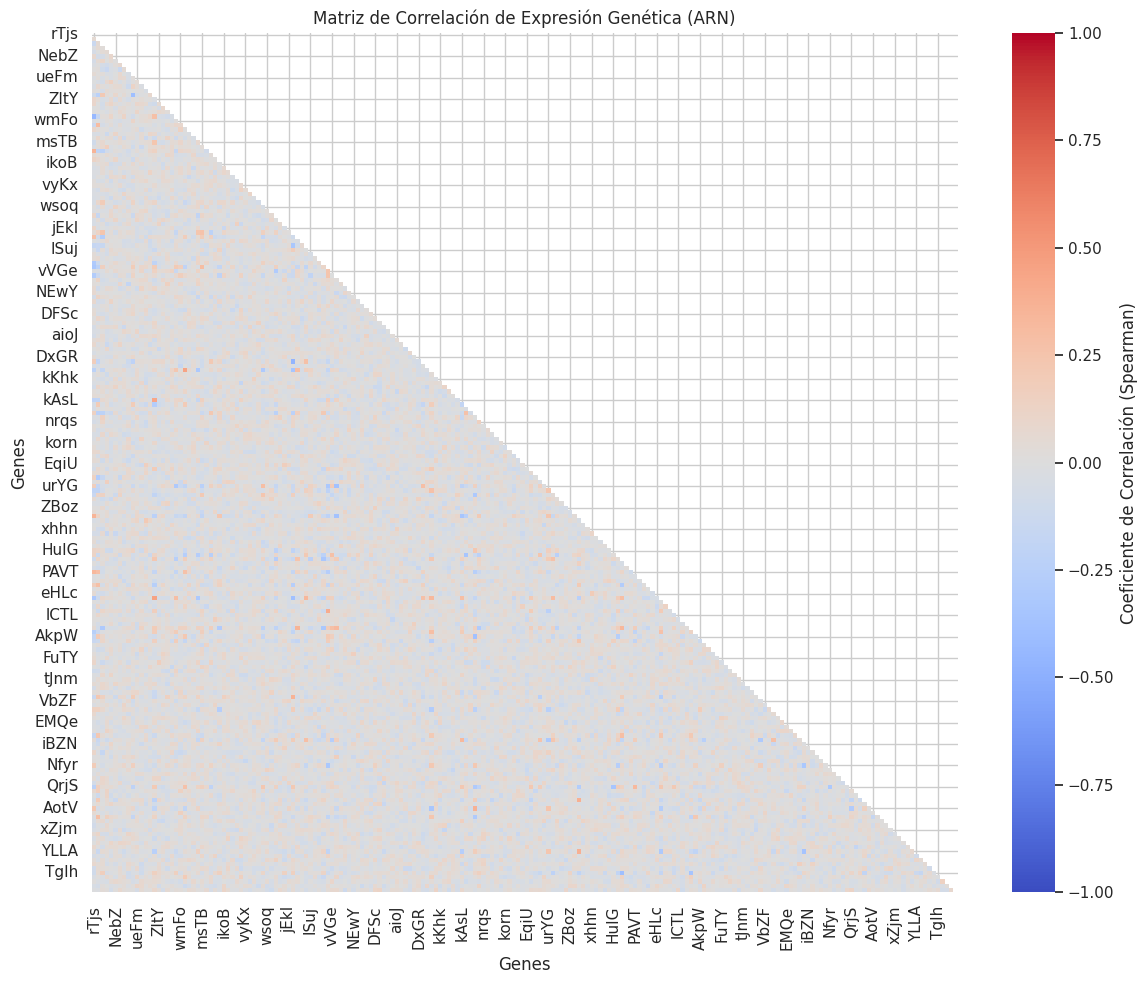

Series([], dtype: float64)


In [533]:
X = df.drop(columns=['target'])

matriz_corr = X.corr(method='spearman')

mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_corr, 
    mask=mask, 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, 
    vmax=1, 
    cbar_kws={'label': 'Coeficiente de Correlación (Spearman)'}
)
plt.title('Matriz de Correlación de Expresión Genética (ARN)')
plt.xlabel('Genes')
plt.ylabel('Genes')
plt.tight_layout()
plt.show()

coeficiente_umbral = 0.7
correlaciones_apiladas = matriz_corr.mask(mask).stack()
correlaciones_fuertes = correlaciones_apiladas[abs(correlaciones_apiladas) > coeficiente_umbral].sort_values(ascending=False)
print(correlaciones_fuertes) # Qué gen tiene una correlación marcada.

#### Correlación dada la Clase

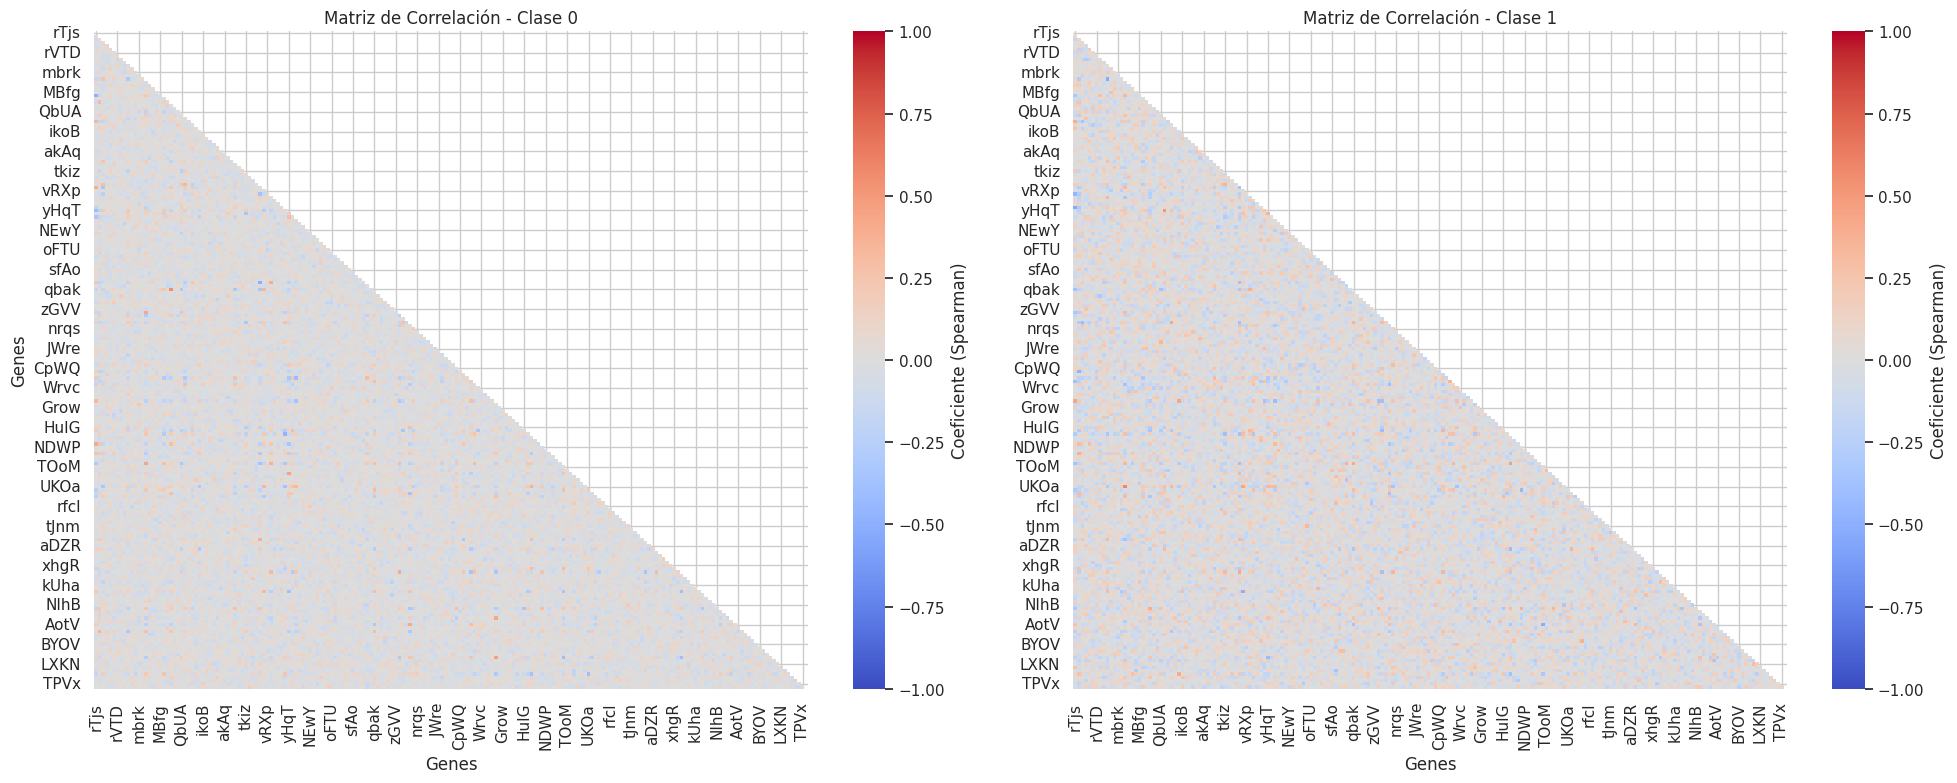

Genes con correlación fuerte en Clase 0:
Series([], dtype: float64)

Genes con correlación fuerte en Clase 1:
Series([], dtype: float64)


In [534]:
X_0 = df[df['target'] == 0].drop(columns=['target'])
X_1 = df[df['target'] == 1].drop(columns=['target'])

corr_0 = X_0.corr(method='spearman')
corr_1 = X_1.corr(method='spearman')

mask = np.triu(np.ones_like(corr_0, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(
    corr_0, 
    mask=mask, 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, 
    vmax=1, 
    ax=axes[0],
    cbar_kws={'label': 'Coeficiente (Spearman)'}
)
axes[0].set_title('Matriz de Correlación - Clase 0')
axes[0].set_xlabel('Genes')
axes[0].set_ylabel('Genes')

sns.heatmap(
    corr_1, 
    mask=mask, 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, 
    vmax=1, 
    ax=axes[1],
    cbar_kws={'label': 'Coeficiente (Spearman)'}
)
axes[1].set_title('Matriz de Correlación - Clase 1')
axes[1].set_xlabel('Genes')
axes[1].set_ylabel('') 

plt.tight_layout()
plt.show()

coeficiente_umbral = 0.7
print("Genes con correlación fuerte en Clase 0:")
correlaciones_apiladas_0 = corr_0.mask(mask).stack()
correlaciones_fuertes_0 = correlaciones_apiladas_0[abs(correlaciones_apiladas_0) > coeficiente_umbral].sort_values(ascending=False)
print(correlaciones_fuertes_0)

print("\nGenes con correlación fuerte en Clase 1:")
correlaciones_apiladas_1 = corr_1.mask(mask).stack()
correlaciones_fuertes_1 = correlaciones_apiladas_1[abs(correlaciones_apiladas_1) > coeficiente_umbral].sort_values(ascending=False)
print(correlaciones_fuertes_1)

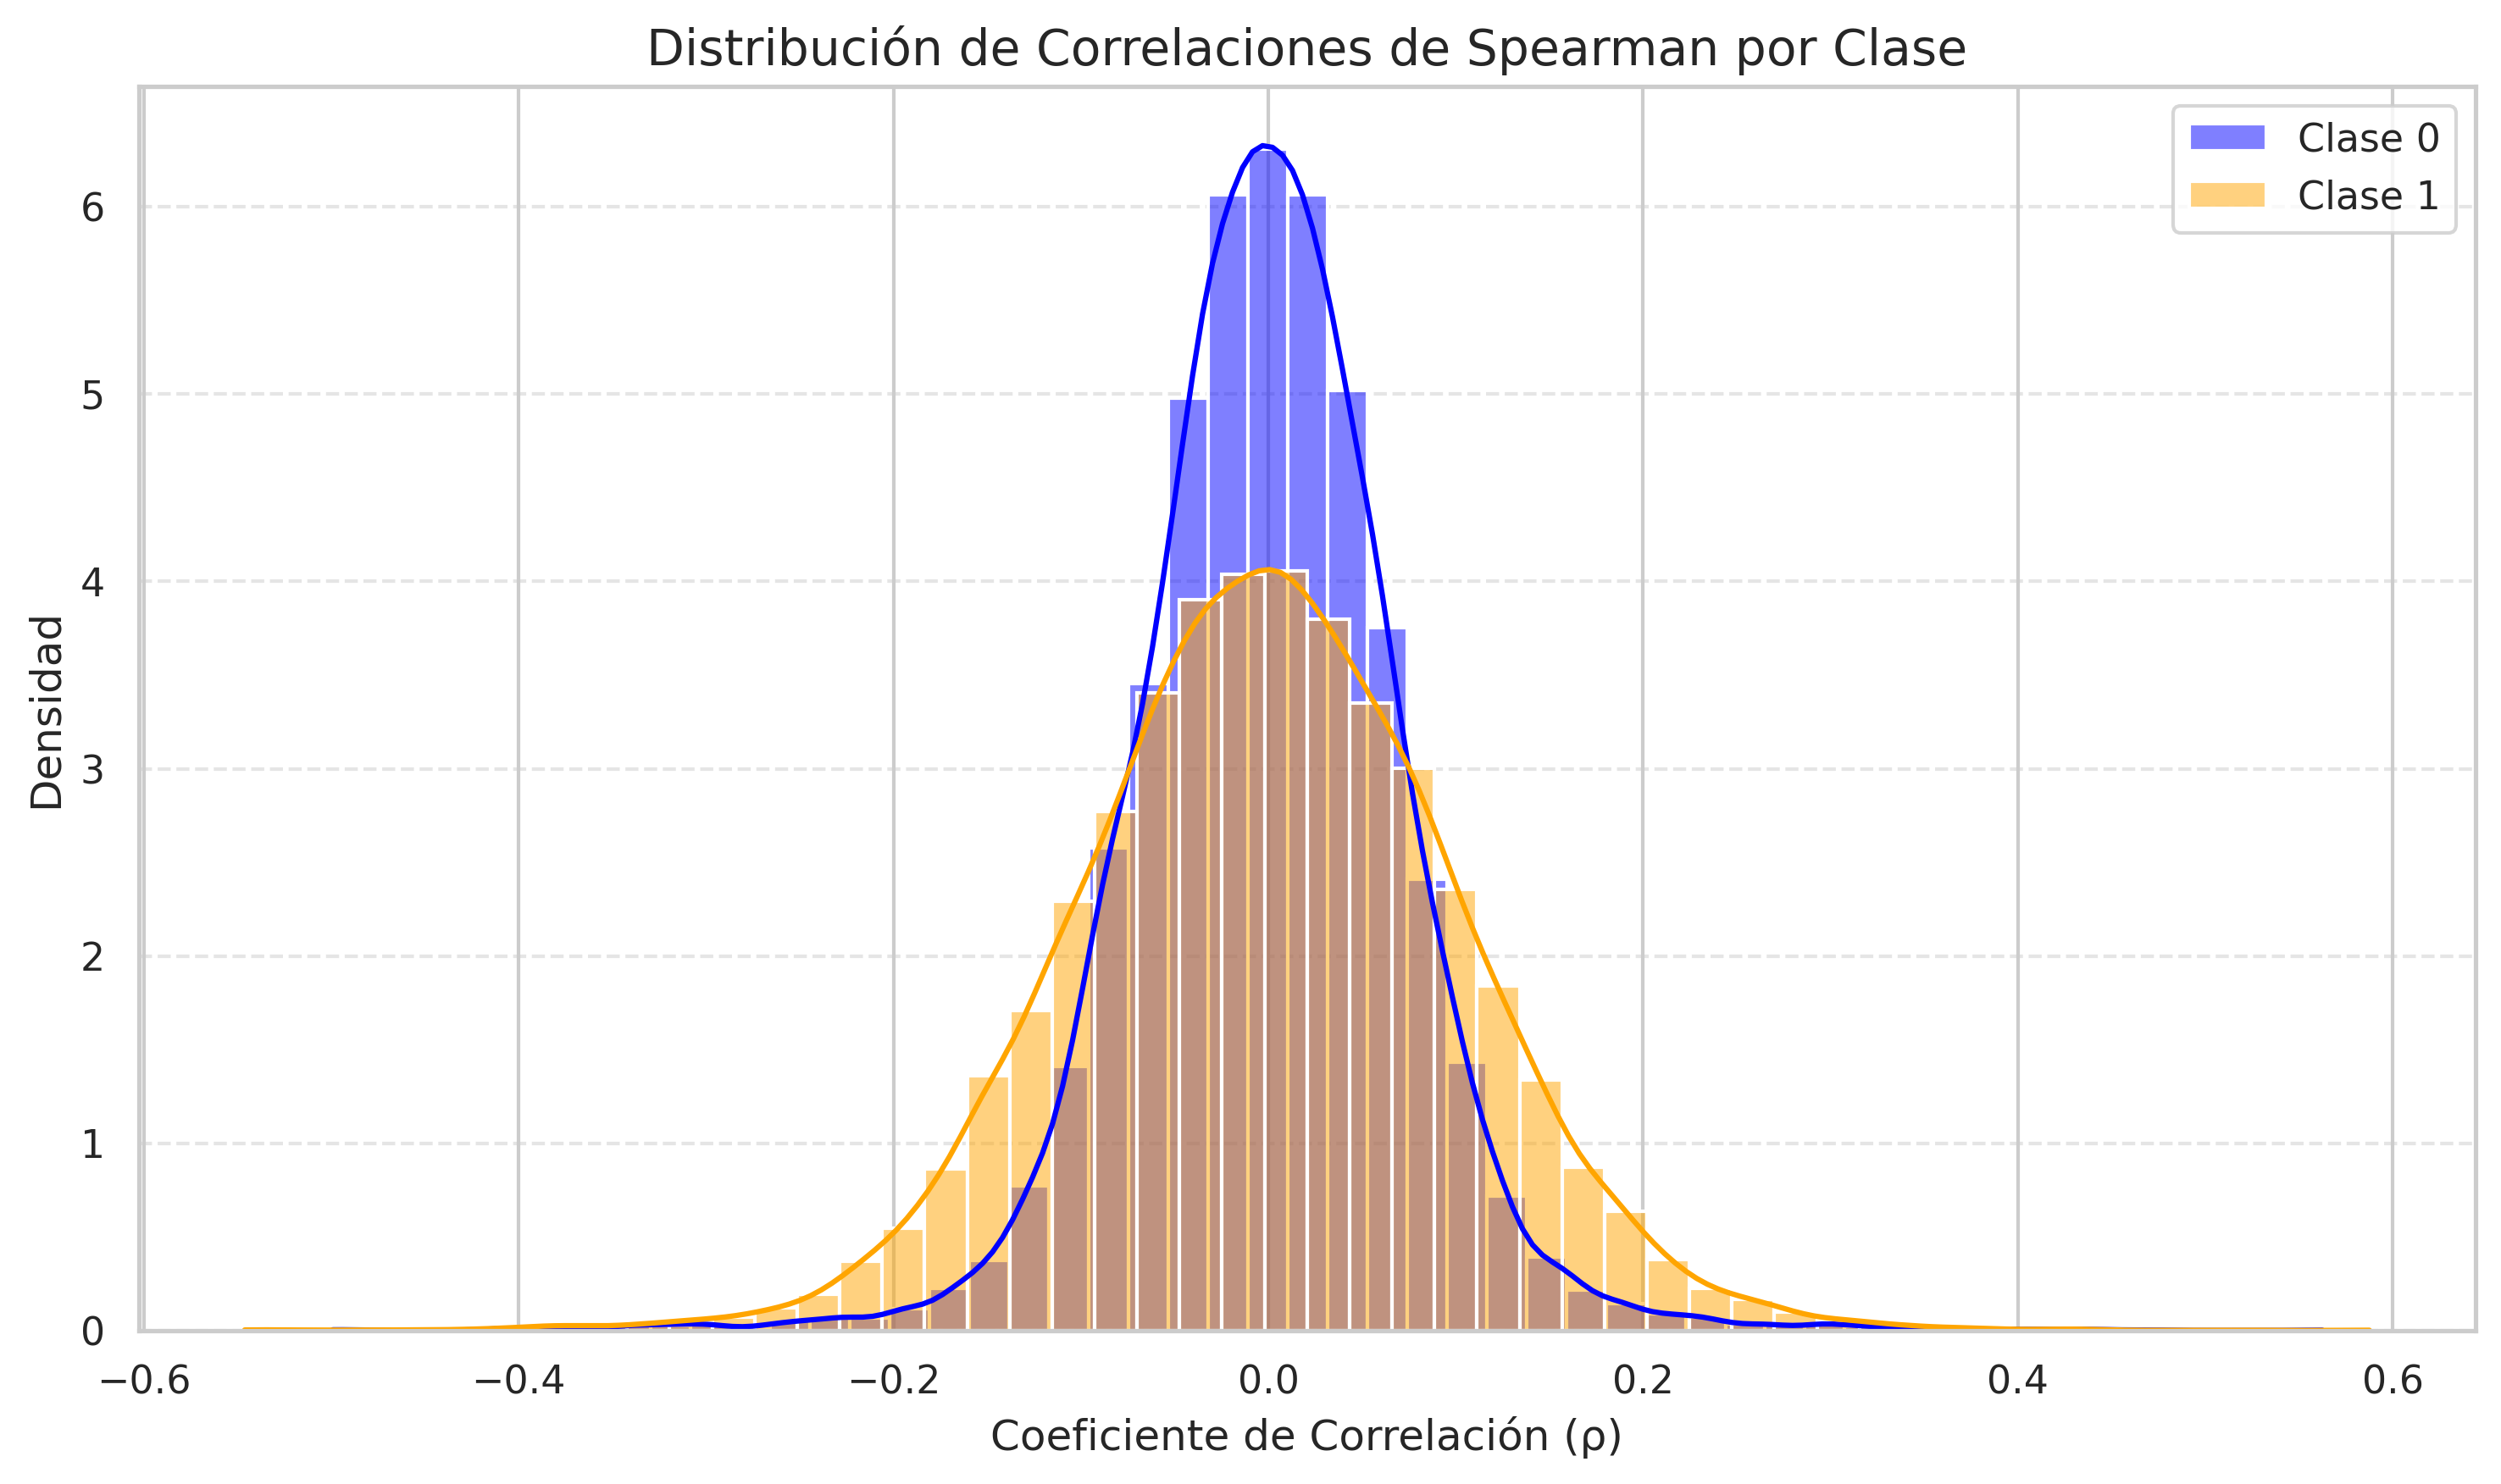

In [ ]:
df_clase0 = df[df['target'] == 0].drop(columns=['target'])
df_clase1 = df[df['target'] == 1].drop(columns=['target'])

matriz_corr0 = df_clase0.corr(method='spearman')
matriz_corr1 = df_clase1.corr(method='spearman')

mascara = np.triu(np.ones(matriz_corr0.shape), k=1).astype(bool)
corr_clase0 = matriz_corr0.where(mascara).stack().values
corr_clase1 = matriz_corr1.where(mascara).stack().values

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6), dpi=300)

sns.histplot(corr_clase0, color='blue', label='Clase 0', kde=True, stat='density', alpha=0.5, edgecolor='white', bins=50)

sns.histplot(corr_clase1, color='orange', label='Clase 1', kde=True, stat='density', alpha=0.5, edgecolor='white', bins=50)

plt.title('Distribución de Correlaciones de Spearman por Clase', fontsize=14)
plt.xlabel('Coeficiente de Correlación (ρ)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Análisis de Normalidad en los Atributos dada la Clase

In [535]:
resultados_condicionales = []

for clase in [0, 1]:
    df_clase = df[df['target'] == clase].drop(columns=['target'])
    
    for gen in df_clase.columns:
        data = df_clase[gen].dropna()
        
        _, p_shapiro = shapiro(data)
        es_normal_shapiro = p_shapiro > 0.05
             
        resultados_condicionales.append({
            'Clase': clase,
            'Gen': gen,
            'p_valor_Shapiro': p_shapiro,
            'Normal_Shapiro': es_normal_shapiro,
        })

df_tests_condicional = pd.DataFrame(resultados_condicionales)

display(df_tests_condicional.sort_values(by=['Clase', 'p_valor_Shapiro'], ascending=[True, True]).head(15))

,Clase,Gen,p_valor_Shapiro,Normal_Shapiro
19,0,Jbcl,0.000274,False
23,0,NtjU,0.001213,False
73,0,cvxh,0.002031,False
12,0,mbrk,0.009235,False
28,0,xDHG,0.012950,False
77,0,qHhS,0.021887,False
122,0,GLoy,0.022820,False
130,0,eHLc,0.031694,False
101,0,SZxQ,0.031777,False
65,0,DFSc,0.033604,False


#### Histogramas de Atributos dada la Clase

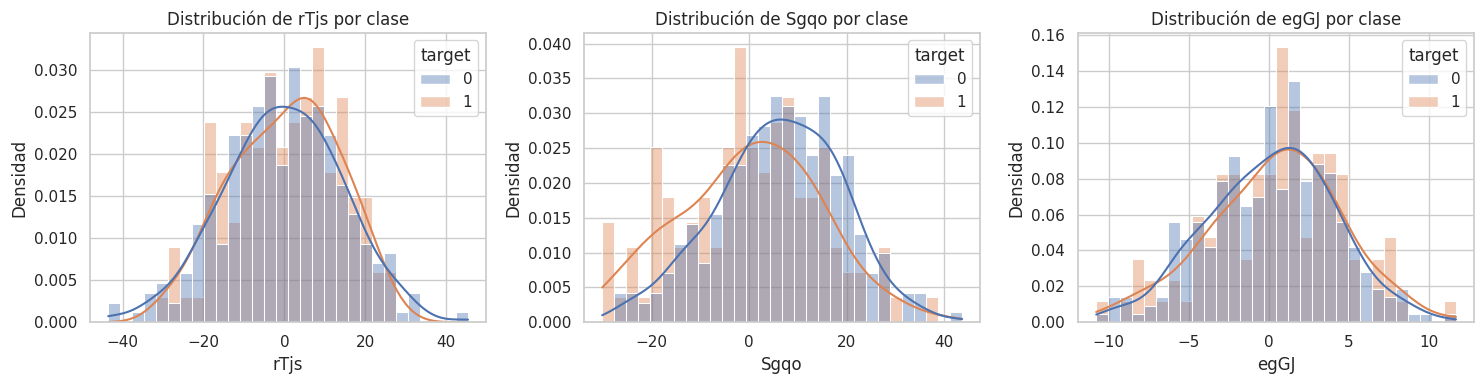

In [536]:
features = [col for col in df.columns if col != 'target']
features = features[:3]#cantidad de genes a graficar

n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(
        data=df,
        x=feature,
        hue='target',
        kde=True,
        stat="density",
        common_norm=False,
        bins=30,
        alpha=0.4,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribución de {feature} por clase")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Densidad")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### OutLiers de las Distribuciones de los Atributos dada la Clase

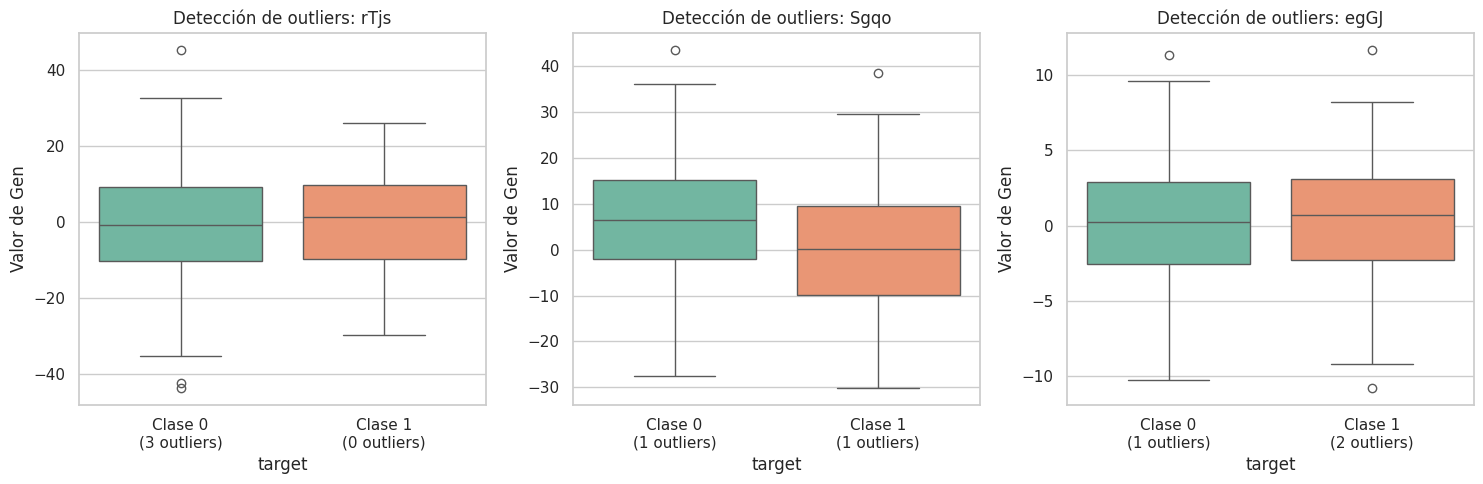

In [537]:
features = [col for col in df.columns if col != 'target'][:3] 

n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=df,
        x='target',
        y=feature,
        hue='target',
        legend=False,
        palette="Set2",
        order=[0, 1],
        ax=axes[i]
    )
    
    axes[i].set_title(f"Detección de outliers: {feature}")
    axes[i].set_ylabel("Valor de Gen")
    
    nuevas_etiquetas = []
    
    for clase in [0, 1]:
        datos_clase = df[df['target'] == clase][feature]
    
        Q1 = datos_clase.quantile(0.25)
        Q3 = datos_clase.quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        cantidad_outliers = datos_clase[(datos_clase < limite_inferior) | (datos_clase > limite_superior)].count()
        
        nuevas_etiquetas.append(f"Clase {clase}\n({cantidad_outliers} outliers)")
        
    axes[i].set_xticks(range(2))
    axes[i].set_xticklabels(nuevas_etiquetas)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Análisis de Normalidad Multivariable dada la Clase

In [538]:
def tests_multivariables(df, nombre_dataset="Dataset", target_col='target'):
   
    print(f"RESULTADOS PARA: {nombre_dataset}")
    print("-" * 50)
    
    X_clase_0 = df[df[target_col] == 0].drop(columns=[target_col])
    X_clase_1 = df[df[target_col] == 1].drop(columns=[target_col])
    
    mvn_0 = pg.multivariate_normality(X_clase_0)
    mvn_1 = pg.multivariate_normality(X_clase_1)
    
    print("Test de Normalidad Multivariable (Henze-Zirkler):")
    print(f"Clase 0 -> Normal: {mvn_0.normal} | p-valor: {mvn_0.pval}")
    print(f"Clase 1 -> Normal: {mvn_1.normal} | p-valor: {mvn_1.pval}\n")
    
    lista_genes = df.drop(columns=[target_col]).columns.tolist()
    
    try:
        res_box = pg.box_m(df, dvs=lista_genes, group=target_col)
        print("Test de Igualdad de Covarianzas (Box's M):")
        print(f"Matrices iguales: {res_box['equal_cov'].iloc[0]} | p-valor: {res_box['pval'].iloc[0]}")
        display(res_box)
    except Exception as e:
        print("Test de Igualdad de Covarianzas (Box's M):")
        print(f"ERROR MATEMÁTICO: {e}")
        
    print("=" * 60, "\n")

In [539]:
tests_multivariables(df, nombre_dataset="Dataset de Desarrollo", target_col='target')

RESULTADOS PARA: Dataset de Desarrollo
--------------------------------------------------
Test de Normalidad Multivariable (Henze-Zirkler):
Clase 0 -> Normal: False | p-valor: 0.0
Clase 1 -> Normal: False | p-valor: 0.0

Test de Igualdad de Covarianzas (Box's M):
Matrices iguales: False | p-valor: nan


/home/nacho/miniconda3/lib/python3.12/site-packages/pingouin/multivariate.py:372: RuntimeWarning: invalid value encountered in power
  M = ((np.linalg.det(covs) / S_det) ** (v / 2)).prod()


,Chi2,df,pval,equal_cov
box,NaN,20100.0,NaN,False


No tiene sentido realizar este test al tener solo 400 datos para 200 atributos. Para calcular la matriz de covarianza de 200 variables se necesitarían estimar unas 20 mil relaciones cruzadas, por lo cual no hay suficientes datos para calcularla de manera estable.   

Sin embargo, si discriminamos por aquellos atributos que tienen la mayor varianza entre las medias de sus distribuciones dada la clase, entonces el test puede brindarnos información sobre qué esta pasando. Resulta ser que de esta manera una de las distribuciones dada la clase si es una Normal Multivariable.  

In [540]:
medias = df.groupby('target').mean()
separacion = medias.var()
atributos_top = separacion.nlargest(40).index.tolist()

df_medias = df[atributos_top + ['target']].copy()

tests_multivariables(df_medias, nombre_dataset="Dataset de Desarrollo (Top 40 Atributos)", target_col='target')

RESULTADOS PARA: Dataset de Desarrollo (Top 40 Atributos)
--------------------------------------------------
Test de Normalidad Multivariable (Henze-Zirkler):
Clase 0 -> Normal: False | p-valor: 2.9642602671529047e-07
Clase 1 -> Normal: True | p-valor: 0.2803911091787315

Test de Igualdad de Covarianzas (Box's M):
Matrices iguales: False | p-valor: 0.0


/home/nacho/miniconda3/lib/python3.12/site-packages/pingouin/multivariate.py:386: RuntimeWarning: divide by zero encountered in log
  u = -2 * (1 - c) * np.log(M)


,Chi2,df,pval,equal_cov
box,inf,820.0,0.0,False


El método inicial solo evaluaba la distancia entre las medias. Para mejorar la selección, es necesario ponderar la importancia de cada atributo penalizando por su varianza. Este enfoque es, en esencia, el Análisis de Varianza (ANOVA).

In [541]:
X = df.drop(columns=['target'])
y = df['target']
k_mejores = 40

selector = SelectKBest(score_func=f_classif, k=k_mejores)
selector.fit(X, y)

atributos_top = X.columns[selector.get_support()].tolist()

df_anova = df[atributos_top + ['target']].copy()

tests_multivariables(df_anova, nombre_dataset="Dataset de Desarrollo (Top 40 Atributos - ANOVA)", target_col='target')

RESULTADOS PARA: Dataset de Desarrollo (Top 40 Atributos - ANOVA)
--------------------------------------------------


Test de Normalidad Multivariable (Henze-Zirkler):
Clase 0 -> Normal: True | p-valor: 0.38680413539578484
Clase 1 -> Normal: True | p-valor: 0.18524697584490663

Test de Igualdad de Covarianzas (Box's M):
Matrices iguales: False | p-valor: 5.256428804252458e-13


,Chi2,df,pval,equal_cov
box,1142.456667,820.0,5.256429e-13,False
